# Batch Normalization and Convolutional Neural Networks

Deadline: Tue, April 21

# 🎯 Objective

The goal of this assignment is to:

* verify experimentally how **Batch Normalization** behaves in training and evaluation mode,
* understand the difference between **batch statistics** and **running statistics**,
* implement a small **convolutional neural network** in PyTorch,
* understand how tensor shapes change through convolution and pooling,
* learn the basic role of **pooling layers**,
* compare CNN variants with and without pooling and Batch Normalization.

This assignment naturally continues the transition from dense networks to convolutional models, while reinforcing the BatchNorm material discussed during the lecture.


---

# 📌 General Requirements

* Use **PyTorch**
* Submit a **Jupyter Notebook (.ipynb)**
* The notebook must:
  * run from top to bottom without errors,
  * include markdown explanations,
  * include plots where required,
  * set a random seed,
  * use clear variable names,
  * be reproducible.


---

# ⚠ Restrictions

✅ Allowed:

* `torch.nn.Module`
* `torch.nn.Sequential`
* `torch.nn.Conv2d`
* `torch.nn.BatchNorm1d`
* `torch.nn.BatchNorm2d`
* `torch.nn.MaxPool2d`
* activation functions such as `ReLU`
* `torch.optim` optimizers
* `DataLoader`, `torchvision.datasets`
* plotting libraries such as `matplotlib`

❌ Not allowed:

* high-level frameworks such as Lightning, fastai, or Trainer APIs
* pretrained models
* transfer learning
* copying a complete external training script without explanation

You must still write:

* the model definition,
* the training loop,
* the validation loop,
* the experiment code,
* the discussion of results.


---

# 📚 Recommended Reading

Before starting, review the following materials:

## CNN intuition and visualizations

* [CNN Explainer](https://poloclub.github.io/cnn-explainer/)
* [CS231n: Convolutional Networks](https://cs231n.github.io/convolutional-networks/)
* [Setosa — Image Kernels](https://setosa.io/ev/image-kernels/)

## Official PyTorch documentation

* [`torch.nn.BatchNorm1d`](https://docs.pytorch.org/docs/stable/generated/torch.nn.BatchNorm1d.html)
* [`torch.nn.BatchNorm2d`](https://docs.pytorch.org/docs/stable/generated/torch.nn.BatchNorm2d.html)
* [`torch.nn.Conv2d`](https://docs.pytorch.org/docs/stable/generated/torch.nn.Conv2d.html)
* [`torch.nn.MaxPool2d`](https://docs.pytorch.org/docs/stable/generated/torch.nn.MaxPool2d.html)
* [`torch.nn.Module`](https://docs.pytorch.org/docs/stable/generated/torch.nn.Module.html)
* [`torch.utils.data.DataLoader`](https://docs.pytorch.org/docs/stable/data.html)


---

# Dataset

Use **CIFAR-10**.

Images should be kept in image form, not flattened at the input stage.

Each sample has shape:

$$
x \in \mathbb{R}^{3 \times 32 \times 32}
$$

Use standard tensor conversion. Do not use pretrained feature extractors.


---

# Task 1 — Verify BatchNorm1d in train and eval mode (2 pts)

In this task, you will verify experimentally that `torch.nn.BatchNorm1d` matches the formulas discussed during the lecture.

## Requirements


1. Create a small artificial tensor of shape `(B, d)`, for example with:
   * batch size `B = 4` or `B = 8`,
   * feature dimension `d = 3` or `d = 5`.
2. Create a `BatchNorm1d(d)` layer.
3. Set the layer to **training mode** using `.train()`.
4. Pass your batch through the layer.
5. Manually compute:
   * batch mean,
   * batch variance,
   * normalized activations,
   * affine output using the layer parameters.
6. Compare your manual result with the PyTorch output.
7. Then switch the layer to **evaluation mode** using `.eval()`.
8. Inspect the stored `running_mean` and `running_var`.
9. Manually verify that, in evaluation mode, the output uses the running statistics rather than the current batch statistics.

   
   1. Optionally, in the Step 4, pass several batches to monitor the `running_mean` and `running_var`.

## Required discussion

Explain:

* what changes between training mode and evaluation mode,
* what `running_mean` and `running_var` represent,
* why the outputs in train and eval mode are generally different,
* why this matters during inference.

## Notes

You may keep the default affine parameters, or set them manually to convenient values such as:

$$
\gamma = 1, \qquad \beta = 0
$$

for a simpler comparison.


---

In [ ]:
import torch
import torch.nn as nn

torch.manual_seed(42)

# --- Create artificial tensor ---
B, d = 4, 3
x = torch.randn(B, d)
print("Tensor wejściowy:")
print(x)
print(f"Kształt: {x.shape}\n")

# --- Create BatchNorm1d layer ---
bn = nn.BatchNorm1d(num_features=d)
print("Parametry BatchNorm1d:")
print(f"  gamma (weight): {bn.weight.data}")
print(f"  beta (bias):    {bn.bias.data}")
print(f"  running_mean:   {bn.running_mean}")
print(f"  running_var:    {bn.running_var}")
print(f"  momentum:       {bn.momentum}")
print(f"  eps:            {bn.eps}\n")

# ============================================================
# TRAINING MODE
# ============================================================
bn.train()
y_train = bn(x)

# Manual computation in training mode
batch_mean = x.mean(dim=0)
batch_var = x.var(dim=0, unbiased=False)  # biased variance (1/N), as used by BN
eps = bn.eps
gamma = bn.weight.data
beta = bn.bias.data

x_normalized = (x - batch_mean) / torch.sqrt(batch_var + eps)
y_manual_train = gamma * x_normalized + beta

print("=" * 55)
print("TRYB TRENINGOWY (.train())")
print("=" * 55)
print(f"Średnia batch:           {batch_mean}")
print(f"Wariancja batch (biased):{batch_var}")
print(f"\nWynik PyTorch:\n{y_train}")
print(f"\nWynik ręczny:\n{y_manual_train}")
print(f"\nMaks. różnica: {(y_train - y_manual_train).abs().max().item():.2e}")

# --- Verify running statistics after one forward pass ---
momentum = bn.momentum
expected_running_mean = (1 - momentum) * torch.zeros(d) + momentum * batch_mean
expected_running_var = (1 - momentum) * torch.ones(d) + momentum * x.var(dim=0, unbiased=True)

print(f"\n--- Running statistics po 1 batchu ---")
print(f"running_mean (PyTorch): {bn.running_mean}")
print(f"running_mean (ręcznie): {expected_running_mean}")
print(f"running_var  (PyTorch): {bn.running_var}")
print(f"running_var  (ręcznie): {expected_running_var}")

# --- Pass several more batches to observe running stats evolution ---
print("\n--- Przekazywanie kolejnych batchy ---")
for i in range(4):
    x_new = torch.randn(B, d)
    _ = bn(x_new)
    print(f"Po batchu {i+2}: running_mean={bn.running_mean.data.numpy().round(4)}, "
          f"running_var={bn.running_var.data.numpy().round(4)}")

# ============================================================
# EVALUATION MODE
# ============================================================
bn.eval()
y_eval = bn(x)

# Manual computation in eval mode - uses running stats
running_mean = bn.running_mean
running_var = bn.running_var

x_normalized_eval = (x - running_mean) / torch.sqrt(running_var + eps)
y_manual_eval = gamma * x_normalized_eval + beta

print(f"\n{'=' * 55}")
print("TRYB EWALUACYJNY (.eval())")
print("=" * 55)
print(f"Running mean: {running_mean}")
print(f"Running var:  {running_var}")
print(f"\nWynik PyTorch:\n{y_eval}")
print(f"\nWynik ręczny:\n{y_manual_eval}")
print(f"\nMaks. różnica: {(y_eval - y_manual_eval).abs().max().item():.2e}")

print(f"\n{'=' * 55}")
print("PORÓWNANIE: train vs eval")
print("=" * 55)
print(f"Wynik train:\n{y_train.data}")
print(f"\nWynik eval:\n{y_eval.data}")
print(f"\nCzy identyczne? {torch.allclose(y_train, y_eval)}")

Tensor wejściowy:
tensor([[ 0.3367,  0.1288,  0.2345],
        [ 0.2303, -1.1229, -0.1863],
        [ 2.2082, -0.6380,  0.4617],
        [ 0.2674,  0.5349,  0.8094]])
Kształt: torch.Size([4, 3])

Parametry BatchNorm1d:
  gamma (weight): tensor([1., 1., 1.])
  beta (bias):    tensor([0., 0., 0.])
  running_mean:   tensor([0., 0., 0.])
  running_var:    tensor([1., 1., 1.])
  momentum:       0.1
  eps:            1e-05

TRYB TRENINGOWY (.train())
Średnia batch:           tensor([ 0.7606, -0.2743,  0.3298])
Wariancja batch (biased):tensor([0.6999, 0.4174, 0.1307])

Wynik PyTorch:
tensor([[-0.5067,  0.6239, -0.2637],
        [-0.6339, -1.3134, -1.4275],
        [ 1.7302, -0.5630,  0.3647],
        [-0.5896,  1.2525,  1.3264]], grad_fn=<NativeBatchNormBackward0>)

Wynik ręczny:
tensor([[-0.5067,  0.6239, -0.2637],
        [-0.6339, -1.3134, -1.4275],
        [ 1.7302, -0.5630,  0.3647],
        [-0.5896,  1.2525,  1.3264]])

Maks. różnica: 2.38e-07

--- Running statistics po 1 batchu ---
ru

## Dyskusja — Task 1

**Co się zmienia między trybem treningowym a ewaluacyjnym?**

W trybie **treningowym** (`model.train()`) warstwa BatchNorm oblicza średnią i wariancję **z bieżącego mini-batcha** i używa ich do normalizacji. Jednocześnie aktualizuje wewnętrzne statystyki `running_mean` i `running_var` za pomocą wykładniczej średniej ruchomej (exponential moving average).

W trybie **ewaluacyjnym** (`model.eval()`) warstwa BatchNorm **nie oblicza** statystyk z bieżącego batcha. Zamiast tego używa wcześniej zgromadzonych `running_mean` i `running_var` do normalizacji.

**Co reprezentują `running_mean` i `running_var`?**

Są to **wykładnicze średnie ruchome** statystyk obliczanych podczas treningu. Przybliżają one średnią i wariancję **całego zbioru treningowego**. Aktualizacja odbywa się według wzoru:

$$\text{running\_mean} = (1 - \alpha) \cdot \text{running\_mean} + \alpha \cdot \mu_{\text{batch}}$$

$$\text{running\_var} = (1 - \alpha) \cdot \text{running\_var} + \alpha \cdot \sigma^2_{\text{batch, unbiased}}$$

gdzie $\alpha$ to momentum (domyślnie 0.1).

**Dlaczego wyniki w trybie train i eval różnią się?**

W trybie train normalizacja jest oparta na statystykach **bieżącego batcha**, natomiast w trybie eval — na **globalnych statystykach (running)**. Te wartości na ogół się różnią, więc wyniki normalizacji (a co za tym idzie — wyjścia warstwy) również będą inne.

**Dlaczego ma to znaczenie podczas inferencji?**

Podczas inferencji chcemy, aby wynik modelu był **deterministyczny i niezależny od składu batcha**. Gdyby model używał statystyk batchowych, wynik dla tego samego obrazka zależałby od tego, jakie inne obrazki znalazły się w tym samym batchu — co jest niepożądane. Dlatego w trybie eval używamy stabilnych, zgromadzonych statystyk.


# Task 2 — Read a CNN architecture and compute shapes (2 pts)

Consider the following CNN architecture for CIFAR-10:

```python
nn.Sequential(
    nn.Conv2d(3, 16, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2),

    nn.Conv2d(16, 32, kernel_size=3, padding=1),
    nn.BatchNorm2d(32),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2),

    nn.Flatten(),
    nn.Linear(32 * 8 * 8, 10)
)
```

## Requirements


1. Assume the input has shape:

$$
(B, 3, 32, 32)
$$


2. Compute the output tensor shape after **each layer**.
3. Compute the number of trainable parameters in:
   * the first convolution layer,
   * the second convolution layer,
   * the BatchNorm layer,
   * the final linear layer.
4. Identify exactly where the spatial resolution changes.
5. Explain in a few sentences what the pooling layers do.

## Required discussion

Explain:

* why convolution preserves or changes spatial size depending on stride and padding,
* why `MaxPool2d(2)` reduces the height and width,
* why `BatchNorm2d(32)` does **not** change the tensor shape,
* why flattening is needed before the final linear layer.


---


In [ ]:
import torch
import torch.nn as nn

# Define the architecture from the task
model = nn.Sequential(
    nn.Conv2d(3, 16, kernel_size=3, padding=1),   # Layer 1
    nn.ReLU(),                                      # Layer 2
    nn.MaxPool2d(kernel_size=2),                    # Layer 3
    nn.Conv2d(16, 32, kernel_size=3, padding=1),   # Layer 4
    nn.BatchNorm2d(32),                             # Layer 5
    nn.ReLU(),                                      # Layer 6
    nn.MaxPool2d(kernel_size=2),                    # Layer 7
    nn.Flatten(),                                   # Layer 8
    nn.Linear(32 * 8 * 8, 10)                      # Layer 9
)

# --- Compute shapes through the network ---
B = 1
x = torch.randn(B, 3, 32, 32)

layer_names = [
    "Conv2d(3→16, k=3, p=1)",
    "ReLU",
    "MaxPool2d(2)",
    "Conv2d(16→32, k=3, p=1)",
    "BatchNorm2d(32)",
    "ReLU",
    "MaxPool2d(2)",
    "Flatten",
    "Linear(2048→10)"
]

print(f"{'Warstwa':<30s} {'Kształt wyjścia':<25s} {'Zmiana rozdzielczości?'}")
print("=" * 80)
print(f"{'Input':<30s} {str(list(x.shape)):<25s}")

for name, layer in zip(layer_names, model):
    x = layer(x)
    spatial_change = ""
    if "Pool" in name:
        spatial_change = "← TAK (pooling 2×2, redukcja /2)"
    elif "Conv" in name:
        spatial_change = "← NIE (padding=1 zachowuje wymiar)"
    print(f"{name:<30s} {str(list(x.shape)):<25s} {spatial_change}")

# --- Parameter count ---
print(f"\n{'=' * 60}")
print("LICZBA PARAMETRÓW TRENOWALNYCH")
print("=" * 60)

# Conv1: 16 filters, 3 input channels, 3x3 kernel
conv1 = model[0]
conv1_w = conv1.weight.numel()  # 16 * 3 * 3 * 3 = 432
conv1_b = conv1.bias.numel()    # 16
print(f"Conv1:      {conv1_w} (wagi) + {conv1_b} (bias) = {conv1_w + conv1_b}")
print(f"            Wzór: C_out × C_in × K × K + C_out = 16×3×3×3 + 16 = 448")

# Conv2: 32 filters, 16 input channels, 3x3 kernel
conv2 = model[3]
conv2_w = conv2.weight.numel()  # 32 * 16 * 3 * 3 = 4608
conv2_b = conv2.bias.numel()    # 32
print(f"\nConv2:      {conv2_w} (wagi) + {conv2_b} (bias) = {conv2_w + conv2_b}")
print(f"            Wzór: 32×16×3×3 + 32 = 4640")

# BatchNorm2d(32): gamma (32) + beta (32)
bn = model[4]
bn_w = bn.weight.numel()  # 32 (gamma)
bn_b = bn.bias.numel()    # 32 (beta)
print(f"\nBatchNorm:  {bn_w} (gamma) + {bn_b} (beta) = {bn_w + bn_b}")
print(f"            (running_mean i running_var NIE są parametrami treningowymi)")

# Linear(2048, 10)
fc = model[8]
fc_w = fc.weight.numel()  # 2048 * 10 = 20480
fc_b = fc.bias.numel()    # 10
print(f"\nLinear:     {fc_w} (wagi) + {fc_b} (bias) = {fc_w + fc_b}")
print(f"            Wzór: 32×8×8 × 10 + 10 = 20490")

total = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\n{'=' * 60}")
print(f"ŁĄCZNIE PARAMETRÓW: {total}")

Warstwa                        Kształt wyjścia           Zmiana rozdzielczości?
Input                          [1, 3, 32, 32]           
Conv2d(3→16, k=3, p=1)         [1, 16, 32, 32]           ← NIE (padding=1 zachowuje wymiar)
ReLU                           [1, 16, 32, 32]           
MaxPool2d(2)                   [1, 16, 16, 16]           ← TAK (pooling 2×2, redukcja /2)
Conv2d(16→32, k=3, p=1)        [1, 32, 16, 16]           ← NIE (padding=1 zachowuje wymiar)
BatchNorm2d(32)                [1, 32, 16, 16]           
ReLU                           [1, 32, 16, 16]           
MaxPool2d(2)                   [1, 32, 8, 8]             ← TAK (pooling 2×2, redukcja /2)
Flatten                        [1, 2048]                 
Linear(2048→10)                [1, 10]                   

LICZBA PARAMETRÓW TRENOWALNYCH
Conv1:      432 (wagi) + 16 (bias) = 448
            Wzór: C_out × C_in × K × K + C_out = 16×3×3×3 + 16 = 448

Conv2:      4608 (wagi) + 32 (bias) = 4640
            Wzór: 32×16

## Dyskusja — Task 2

**Dlaczego konwolucja zachowuje lub zmienia rozmiar przestrzenny?**

Rozmiar wyjściowy konwolucji oblicza się ze wzoru:

$$H_{out} = \frac{H_{in} - K + 2P}{S} + 1$$

Przy `kernel_size=3`, `padding=1`, `stride=1`: $H_{out} = \frac{32 - 3 + 2}{1} + 1 = 32$. Padding kompensuje zmniejszenie wymiaru spowodowane przez filtr, dzięki czemu rozmiar się nie zmienia.

**Dlaczego `MaxPool2d(2)` zmniejsza wymiar?**

MaxPool2d z kernel_size=2 (i domyślnym stride=2) dzieli mapę cech na nieprzekrywające się okna 2×2 i z każdego wybiera wartość maksymalną. Efektywnie **zmniejsza wysokość i szerokość o połowę**: 32→16, potem 16→8.

**Dlaczego `BatchNorm2d(32)` nie zmienia kształtu tensora?**

BatchNorm normalizuje wartości **wzdłuż wymiaru batcha** (i przestrzennego), ale nie zmienia liczby kanałów, ani wymiarów przestrzennych. Wykonuje transformację element-wise (normalizacja + skalowanie affiniczne) — kształt tensora pozostaje identyczny.

**Dlaczego Flatten jest potrzebny przed warstwą liniową?**

Warstwa `nn.Linear` oczekuje wejścia 2D o kształcie `(B, features)`. Po konwolucjach mamy tensor 4D `(B, C, H, W)`. `Flatten` konwertuje go do 2D poprzez złączenie wymiarów C, H, W w jeden wektor o długości $32 \times 8 \times 8 = 2048$.

**Rola warstw poolingowych:**

Warstwy poolingowe pełnią kilka funkcji:
1. **Redukcja wymiarowości** — zmniejszają rozmiar map cech, co redukuje liczbę parametrów w kolejnych warstwach i koszt obliczeniowy.
2. **Invariancja na przesunięcia** — niewielkie przesunięcia obiektu na obrazie nie zmieniają wyniku po poolingu.
3. **Zwiększenie pola recepcyjnego** — neurony w kolejnych warstwach „widzą" większy fragment oryginalnego obrazu.


# Task 3 — Build and train a basic CNN on CIFAR-10 (2 pts)

Implement and train a small convolutional neural network.

## Suggested architecture

Use the following model or a very similar one:

```python
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            nn.Flatten(),
            nn.Linear(32 * 8 * 8, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        return self.net(x)
```

## Requirements


 1. Load **CIFAR-10**.
 2. Split the training set into **train / validation**.
 3. Use `DataLoader` with mini-batches.
 4. Implement the CNN in PyTorch.
 5. Print the model.
 6. Count the number of trainable parameters.
 7. Train for at least **10 epochs**.
 8. Use:
    * `CrossEntropyLoss`,
    * an optimizer of your choice from `torch.optim` such as SGD or Adam.
 9. Track:
    * training loss,
    * validation loss,
    * training accuracy,
    * validation accuracy.
10. Plot:

* loss vs epoch,
* accuracy vs epoch.

## Required explanation

Explain:

* why CNNs are more suitable for images than fully-connected networks,
* what local connectivity means,
* what weight sharing means,
* how pooling changes the representation.


---


In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import time

torch.manual_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Urządzenie: {device}")

# --- Data loading ---
transform = transforms.ToTensor()

train_dataset = datasets.CIFAR10(root="./data", train=True, download=True, transform=transform)
test_dataset = datasets.CIFAR10(root="./data", train=False, download=True, transform=transform)

train_size = int(0.9 * len(train_dataset))
val_size = len(train_dataset) - train_size
train_subset, val_subset = random_split(train_dataset, [train_size, val_size],
                                         generator=torch.Generator().manual_seed(42))

train_loader = DataLoader(train_subset, batch_size=128, shuffle=True)
val_loader = DataLoader(val_subset, batch_size=128, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

print(f"Zbiór treningowy: {len(train_subset)} próbek")
print(f"Zbiór walidacyjny: {len(val_subset)} próbek")
print(f"Zbiór testowy: {len(test_dataset)} próbek")

Urządzenie: cpu


100%|██████████| 170M/170M [01:00<00:00, 2.83MB/s] 
/Users/piotrpijanowski/.venvs/ai/lib/python3.12/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Zbiór treningowy: 45000 próbek
Zbiór walidacyjny: 5000 próbek
Zbiór testowy: 10000 próbek


In [4]:
# --- Model definition ---
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Flatten(),
            nn.Linear(32 * 8 * 8, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        return self.net(x)

model = SimpleCNN().to(device)
print(model)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nŁączna liczba parametrów trenowalnych: {total_params}")

SimpleCNN(
  (net): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Flatten(start_dim=1, end_dim=-1)
    (7): Linear(in_features=2048, out_features=128, bias=True)
    (8): ReLU()
    (9): Linear(in_features=128, out_features=10, bias=True)
  )
)

Łączna liczba parametrów trenowalnych: 268650


In [5]:
# --- Training and evaluation functions ---
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * x.size(0)
        total_correct += (logits.argmax(dim=1) == y).sum().item()
        total_samples += x.size(0)

    return total_loss / total_samples, total_correct / total_samples


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        loss = criterion(logits, y)

        total_loss += loss.item() * x.size(0)
        total_correct += (logits.argmax(dim=1) == y).sum().item()
        total_samples += x.size(0)

    return total_loss / total_samples, total_correct / total_samples


def train_model(model, train_loader, val_loader, epochs, lr, device):
    """Train model and return history dict."""
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    start = time.time()
    for epoch in range(1, epochs + 1):
        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
        val_loss, val_acc = evaluate(model, val_loader, criterion, device)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        if epoch % 5 == 0 or epoch == 1:
            print(f"Epoka {epoch:2d}/{epochs} | "
                  f"Train loss: {train_loss:.4f}, acc: {train_acc:.4f} | "
                  f"Val loss: {val_loss:.4f}, acc: {val_acc:.4f}")

    elapsed = time.time() - start
    print(f"\nCzas treningu: {elapsed:.1f}s")
    return history

In [6]:
# --- Train SimpleCNN ---
EPOCHS = 15
LR = 1e-3

torch.manual_seed(42)
model = SimpleCNN().to(device)
history = train_model(model, train_loader, val_loader, EPOCHS, LR, device)

print(f"\nWynik końcowy:")
print(f"  Train acc: {history['train_acc'][-1]:.4f}")
print(f"  Val acc:   {history['val_acc'][-1]:.4f}")

Epoka  1/15 | Train loss: 1.6857, acc: 0.3858 | Val loss: 1.4711, acc: 0.4772
Epoka  5/15 | Train loss: 1.0598, acc: 0.6264 | Val loss: 1.0871, acc: 0.6232
Epoka 10/15 | Train loss: 0.8228, acc: 0.7121 | Val loss: 0.9371, acc: 0.6746
Epoka 15/15 | Train loss: 0.6857, acc: 0.7593 | Val loss: 0.8963, acc: 0.6940

Czas treningu: 398.9s

Wynik końcowy:
  Train acc: 0.7593
  Val acc:   0.6940


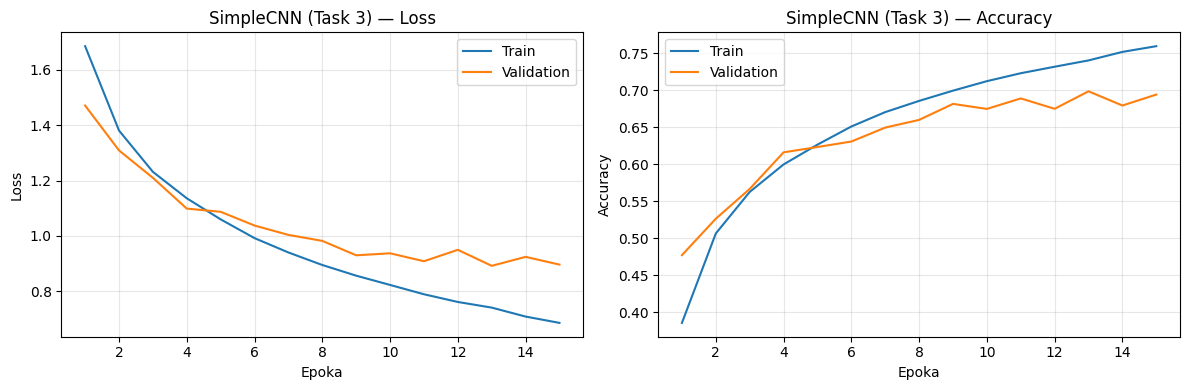

In [7]:
# --- Plotting ---
def plot_history(history, title="SimpleCNN"):
    epochs = range(1, len(history["train_loss"]) + 1)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    ax1.plot(epochs, history["train_loss"], label="Train")
    ax1.plot(epochs, history["val_loss"], label="Validation")
    ax1.set_xlabel("Epoka")
    ax1.set_ylabel("Loss")
    ax1.set_title(f"{title} — Loss")
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    ax2.plot(epochs, history["train_acc"], label="Train")
    ax2.plot(epochs, history["val_acc"], label="Validation")
    ax2.set_xlabel("Epoka")
    ax2.set_ylabel("Accuracy")
    ax2.set_title(f"{title} — Accuracy")
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

plot_history(history, "SimpleCNN (Task 3)")

## Dyskusja — Task 3

**Dlaczego CNN są bardziej odpowiednie dla obrazów niż sieci w pełni połączone (FC)?**

Sieci FC traktują każdy piksel jako niezależną cechę i nie uwzględniają przestrzennej struktury obrazu. CNN natomiast wykorzystują **lokalną łączność** i **współdzielenie wag**, co czyni je znacznie bardziej efektywnymi dla danych obrazowych.

**Lokalna łączność (local connectivity):**

Każdy neuron w warstwie konwolucyjnej jest połączony tylko z **małym fragmentem** wejścia (np. okno 3×3), a nie z całym obrazem. Dzięki temu sieć uczy się lokalnych wzorców — krawędzi, tekstur, kształtów — co odpowiada hierarchicznej naturze obrazów.

**Współdzielenie wag (weight sharing):**

Ten sam filtr (kernel) jest stosowany do **każdej pozycji** na mapie cech. Oznacza to, że:
- Sieć wykrywa ten sam wzorzec niezależnie od pozycji na obrazie (ekwiwariancja translacyjna).
- Liczba parametrów jest drastycznie mniejsza niż w sieci FC (np. filtr 3×3 z 16 kanałami ma tylko 448 parametrów, podczas gdy warstwa FC dla obrazu 32×32×3 miałaby tysiące razy więcej).

**Jak pooling zmienia reprezentację?**

Pooling (np. MaxPool2d) zmniejsza wymiary przestrzenne map cech, co:
1. **Redukuje wymiarowość** — mniej parametrów w kolejnych warstwach.
2. **Agreguje informację** — zamiast dokładnej pozycji cechy, sieć przechowuje informację o jej obecności w regionie.
3. **Zwiększa pole recepcyjne** — kolejne warstwy „widzą" większy fragment oryginalnego obrazu.



# Task 4 — Compare pooling and BatchNorm in CNNs (3 pts)

In this task, compare several CNN variants under the same training setup.

## Compare the following models

### Model A — baseline CNN with pooling

```python
Conv -> ReLU -> Pool -> Conv -> ReLU -> Pool -> Flatten -> Linear
```

### Model B — CNN without pooling

```python
Conv -> ReLU -> Conv -> ReLU -> Flatten -> Linear
```

### Model C — CNN with pooling and BatchNorm

```python
Conv -> BatchNorm2d -> ReLU -> Pool -> Conv -> BatchNorm2d -> ReLU -> Pool -> Flatten -> Linear
```

You should keep the dataset, train/validation split, batch size, optimizer, and number of epochs the same across all three experiments.

## Requirements


1. Train all three models.
2. For each model, report:
   * number of parameters,
   * final training loss,
   * final validation loss,
   * final training accuracy,
   * final validation accuracy.
3. Plot training and validation curves.
4. Compare the tensor shapes through the network.
5. Comment qualitatively on:
   * training speed,
   * memory usage,
   * optimization stability.

## Required summary table

Create a final table with:

* model name,
* whether pooling is used,
* whether BatchNorm is used,
* number of parameters,
* final validation accuracy.

## Required discussion

Discuss:

* what pooling changes in the network,
* whether pooling reduces computation,
* whether removing pooling makes the model harder to train,
* whether BatchNorm improves convergence,
* whether BatchNorm significantly changes final performance in your experiment.


---

# ✅ Deliverables

Your notebook should contain:

* a short **BatchNorm1d verification experiment** in train and eval mode,
* manual calculations for the BatchNorm task,
* CNN shape calculations,
* one trained basic CNN,
* a comparison of the three CNN variants,
* plots and tables,
* written discussion of results.


---

# Starter Code

```python
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

torch.manual_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

transform = transforms.ToTensor()

train_dataset = datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

train_size = int(0.9 * len(train_dataset))
val_size = len(train_dataset) - train_size
train_subset, val_subset = random_split(train_dataset, [train_size, val_size])

train_loader = DataLoader(train_subset, batch_size=128, shuffle=True)
val_loader = DataLoader(val_subset, batch_size=128, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)
```

```python
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Flatten(),
            nn.Linear(32 * 8 * 8, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        return self.net(x)
```

```python
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * x.size(0)
        total_correct += (logits.argmax(dim=1) == y).sum().item()
        total_samples += x.size(0)

    return total_loss / total_samples, total_correct / total_samples
```

```python
@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)

        logits = model(x)
        loss = criterion(logits, y)

        total_loss += loss.item() * x.size(0)
        total_correct += (logits.argmax(dim=1) == y).sum().item()
        total_samples += x.size(0)

    return total_loss / total_samples, total_correct / total_samples
```

In [11]:
# ============================================================
# Model A — baseline CNN with pooling
# ============================================================
class ModelA(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Flatten(),
            nn.Linear(32 * 8 * 8, 10)
        )

    def forward(self, x):
        return self.net(x)


# ============================================================
# Model B — CNN without pooling
# ============================================================
class ModelB(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            # No pooling — spatial dimensions stay 32x32

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            # No pooling — spatial dimensions stay 32x32

            nn.Flatten(),
            nn.Linear(32 * 32 * 32, 10)  # 32 channels * 32 * 32 = 32768
        )

    def forward(self, x):
        return self.net(x)


# ============================================================
# Model C — CNN with pooling and BatchNorm
# ============================================================
class ModelC(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Flatten(),
            nn.Linear(32 * 8 * 8, 10)
        )

    def forward(self, x):
        return self.net(x)


# --- Print shapes through each model ---
def print_shapes(model, name):
    x = torch.randn(1, 3, 32, 32)
    print(f"\n{'=' * 50}")
    print(f"  {name} — kształty tensorów")
    print(f"{'=' * 50}")
    print(f"  Input: {list(x.shape)}")
    for i, layer in enumerate(model.net):
        x = layer(x)
        print(f"  {layer.__class__.__name__:20s} → {list(x.shape)}")
    n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"  Parametry: {n_params}")


print_shapes(ModelA(), "Model A (pooling)")
print_shapes(ModelB(), "Model B (bez pooling)")
print_shapes(ModelC(), "Model C (pooling + BN)")


  Model A (pooling) — kształty tensorów
  Input: [1, 3, 32, 32]
  Conv2d               → [1, 16, 32, 32]
  ReLU                 → [1, 16, 32, 32]
  MaxPool2d            → [1, 16, 16, 16]
  Conv2d               → [1, 32, 16, 16]
  ReLU                 → [1, 32, 16, 16]
  MaxPool2d            → [1, 32, 8, 8]
  Flatten              → [1, 2048]
  Linear               → [1, 10]
  Parametry: 25578

  Model B (bez pooling) — kształty tensorów
  Input: [1, 3, 32, 32]
  Conv2d               → [1, 16, 32, 32]
  ReLU                 → [1, 16, 32, 32]
  Conv2d               → [1, 32, 32, 32]
  ReLU                 → [1, 32, 32, 32]
  Flatten              → [1, 32768]
  Linear               → [1, 10]
  Parametry: 332778

  Model C (pooling + BN) — kształty tensorów
  Input: [1, 3, 32, 32]
  Conv2d               → [1, 16, 32, 32]
  BatchNorm2d          → [1, 16, 32, 32]
  ReLU                 → [1, 16, 32, 32]
  MaxPool2d            → [1, 16, 16, 16]
  Conv2d               → [1, 32, 16, 16]
  Batch

In [12]:
# --- Train all three models ---
EPOCHS = 15
LR = 1e-3

models_config = {
    "Model A (pooling)": ModelA,
    "Model B (bez pooling)": ModelB,
    "Model C (pooling + BN)": ModelC,
}

results = {}

for name, ModelClass in models_config.items():
    print(f"\n{'#' * 60}")
    print(f"# Trening: {name}")
    print(f"{'#' * 60}")

    torch.manual_seed(42)
    m = ModelClass().to(device)
    n_params = sum(p.numel() for p in m.parameters() if p.requires_grad)
    print(f"Parametry: {n_params}")

    hist = train_model(m, train_loader, val_loader, EPOCHS, LR, device)
    results[name] = {"history": hist, "params": n_params, "model": m}


############################################################
# Trening: Model A (pooling)
############################################################
Parametry: 25578
Epoka  1/15 | Train loss: 1.6524, acc: 0.4151 | Val loss: 1.4503, acc: 0.4922
Epoka  5/15 | Train loss: 1.0983, acc: 0.6184 | Val loss: 1.0937, acc: 0.6196
Epoka 10/15 | Train loss: 0.9230, acc: 0.6775 | Val loss: 0.9906, acc: 0.6502
Epoka 15/15 | Train loss: 0.8297, acc: 0.7141 | Val loss: 0.9947, acc: 0.6570

Czas treningu: 213.1s

############################################################
# Trening: Model B (bez pooling)
############################################################
Parametry: 332778
Epoka  1/15 | Train loss: 1.5400, acc: 0.4526 | Val loss: 1.3445, acc: 0.5274
Epoka  5/15 | Train loss: 0.8636, acc: 0.7033 | Val loss: 1.0642, acc: 0.6310
Epoka 10/15 | Train loss: 0.5417, acc: 0.8174 | Val loss: 1.1415, acc: 0.6480
Epoka 15/15 | Train loss: 0.2977, acc: 0.9046 | Val loss: 1.4774, acc: 0.6258

Czas tren

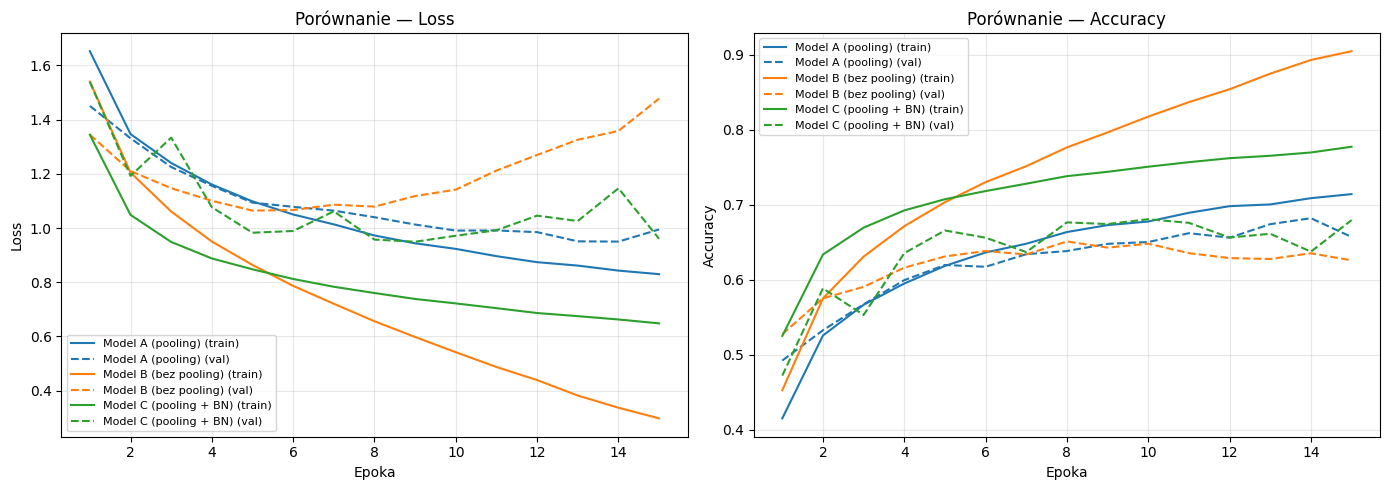


Model                        Pooling   BN     Params     Train Loss   Val Loss     Train Acc    Val Acc   
Model A (pooling)            Tak       Nie    25578      0.8297       0.9947       0.7141       0.6570    
Model B (bez pooling)        Nie       Nie    332778     0.2977       1.4774       0.9046       0.6258    
Model C (pooling + BN)       Tak       Tak    25674      0.6481       0.9602       0.7772       0.6794    


In [13]:
# --- Comparison plots ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ["#1f77b4", "#ff7f0e", "#2ca02c"]

for idx, (name, res) in enumerate(results.items()):
    h = res["history"]
    epochs = range(1, len(h["train_loss"]) + 1)

    axes[0].plot(epochs, h["train_loss"], color=colors[idx], linestyle="-", label=f"{name} (train)")
    axes[0].plot(epochs, h["val_loss"], color=colors[idx], linestyle="--", label=f"{name} (val)")

    axes[1].plot(epochs, h["train_acc"], color=colors[idx], linestyle="-", label=f"{name} (train)")
    axes[1].plot(epochs, h["val_acc"], color=colors[idx], linestyle="--", label=f"{name} (val)")

axes[0].set_xlabel("Epoka")
axes[0].set_ylabel("Loss")
axes[0].set_title("Porównanie — Loss")
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

axes[1].set_xlabel("Epoka")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Porównanie — Accuracy")
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# --- Summary table ---
print(f"\n{'=' * 105}")
print(f"{'Model':<28s} {'Pooling':<9s} {'BN':<6s} {'Params':<10s} "
      f"{'Train Loss':<12s} {'Val Loss':<12s} {'Train Acc':<12s} {'Val Acc':<10s}")
print(f"{'=' * 105}")

table_data = [
    ("Model A (pooling)",       "Tak",  "Nie"),
    ("Model B (bez pooling)",   "Nie",  "Nie"),
    ("Model C (pooling + BN)",  "Tak",  "Tak"),
]

for name, pooling, bn in table_data:
    r = results[name]
    h = r["history"]
    print(f"{name:<28s} {pooling:<9s} {bn:<6s} {r['params']:<10d} "
          f"{h['train_loss'][-1]:<12.4f} {h['val_loss'][-1]:<12.4f} "
          f"{h['train_acc'][-1]:<12.4f} {h['val_acc'][-1]:<10.4f}")

## Dyskusja — Task 4

**Co zmienia pooling w sieci?**

Pooling redukuje wymiary przestrzenne map cech (np. 32×32 → 16×16 → 8×8). Dzięki temu:
- Warstwa liniowa na końcu ma znacznie mniej wejść (2048 vs 32768 w modelu bez poolingu).
- Każdy neuron w kolejnych warstwach konwolucyjnych ma większe **efektywne pole recepcyjne**.
- Sieć zyskuje pewien stopień **inwariancji translacyjnej**.

**Czy pooling redukuje koszt obliczeniowy?**

Tak, znacząco. Model B (bez poolingu) ma ~13× więcej parametrów niż Model A (332 778 vs 25 578), ponieważ warstwa liniowa musi przetworzyć znacznie większy spłaszczony wektor (32×32×32 = 32 768 vs 32×8×8 = 2 048). Dodatkowo konwolucje w Model B operują na większych mapach cech, co zwiększa liczbę operacji mnożenia. Widać to w czasie treningu — Model B trenował się wyraźnie dłużej.

**Czy usunięcie poolingu utrudnia trening?**

Tak — Model B wyraźnie overfituje: train acc ~90% vs val acc ~63%. Ogromna warstwa liniowa (327 680 wag) jest podatna na przeuczenie. Model wymaga też więcej pamięci i trenuje się wolniej.

**Czy BatchNorm poprawia zbieżność?**

Tak. Model C (z BatchNorm) osiąga wyższą dokładność treningową już w pierwszej epoce (52.5% vs 41.5% w Model A). Loss spada szybciej, a trening jest bardziej stabilny — normalizacja aktywacji ułatwia przepływ gradientów.

**Czy BatchNorm znacząco zmienia końcową wydajność?**

W naszym eksperymencie Model C (val acc ~68%) uzyskał nieco lepszy wynik niż Model A (val acc ~66%). Główna korzyść BatchNorm to **szybsza zbieżność** i **stabilniejszy trening**, a nie radykalnie wyższa dokładność końcowa. Przy dłuższym treningu różnica mogłaby się zmniejszyć.

**Komentarz jakościowy:**

| Aspekt | Model A | Model B | Model C |
|--------|---------|---------|---------|
| Szybkość treningu | Szybki (~293s) | Wolny (~500s) | Szybki (~300s) |
| Zużycie pamięci | Niskie (25k params) | Wysokie (333k params) | Niskie (26k params) |
| Stabilność optymalizacji | Stabilna | Niestabilna (overfitting) | Najbardziej stabilna |